# Whiskey Clustering Analysis


## 1. Introduction

Clustering is an unsupervised method used to find natural groupings in data. As [Data Science for Business](https://learning.oreilly.com/library/view/data-science-for/9781449374273/ch06.html#sixdot4dot3_nearest_neighbors_revisited) notes, “we want to perform unsupervised segmentation: finding groups that ‘naturally’ occur.” In this project, I apply clustering to Scotch whisky data to explore similarity in characteristics such as color and flavor.

Using [Scikit Learn](https://scikit-learn.org/stable/user_guide.html) methods, this project compare **KMeans**, which assumes clear, centroid-based clusters, with **hierarchical** clustering, which reveals the full structure of similarity through a dendrogram. Given the **high-dimensional, mostly binary features**, this project evaluates **hierarchinal method better** captures the data’s structure.

## 2. A glance at the Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [86]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/scotch.csv"
df = pd.read_csv(path, header=1)
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,NAME,Unnamed: 1,wyne,yellow,v.pale,pale,p.gold,gold,o.gold,f.gold,...,DISTRICT,islay,midland,spey,east,west,north,lowland,campbell,islands
0,Aberfeldy,Aberfeldy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,MIDLAND,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Aberlour,Aberlour,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Ardberg,Ardberg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,SOUTH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ardmore,Ardmore,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Auchentoshan,Auchentosh,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,WEST,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,Aultmore,Aultmore,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Balblair,Balblair,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NORTH,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,Balmenach,Balmenach,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Balvenie,Balvenie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Banff,Banff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,SPEY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Clustering

#### Data Cleaning

The data should meet 2 goals for clustering:

* Create one clean numeric matrix for clustering
* Keep a separate version with names for interpretation

In [42]:
# drop duplicate column
df_clean = df.drop(columns=["Unnamed: 1"], errors="ignore")

# save names
names = df_clean["NAME"]

# drop text columns
df_features = df_clean.drop(columns=["NAME", "DISTRICT"], errors="ignore")

# drop region columns
region_cols = ["islay", "midland", "spey", "east", "west", "north", "lowland", "campbell", "islands"]
df_features = df_features.drop(columns=region_cols, errors="ignore")

# convert to numeric
df_features = df_features.apply(pd.to_numeric, errors="coerce")

# fill missing
df_features = df_features.fillna(0)

# remove constant columns
df_features = df_features.loc[:, df_features.var() > 0]

df_features.head()

,wyne,yellow,v.pale,pale,p.gold,gold,o.gold,f.gold,bronze,p.amber,...,arome.1,ling,long,very,quick,AGE,DIST,SCORE,%,north
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-9.0,2.0,69.0,40.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,12.0,4.0,83.0,43.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10.0,4.0,85.0,40.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,18.0,2.0,66.0,46.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10.0,5.0,85.0,40.0,0.0


In [74]:
# scale first
X_scaled = StandardScaler().fit_transform(df_features)

# compute distance from center
distances = np.linalg.norm(X_scaled, axis=1)

# remove top 1 extreme outlier
threshold = np.percentile(distances, 99)
mask = distances < threshold

# apply mask to both dataframes
df_features = df_features[mask].reset_index(drop=True)
df_clean = df_clean[mask].reset_index(drop=True)

### (1) Hierarchical Clustering

Hierarchical clustering builds a tree (dendrogram) showing how whiskies merge based on similarity, allowing flexible selection of cluster numbers.

#### Standardize

In [75]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(df_features)

#### Plot Hierarchical Clustering Dendrogram
Plots the corresponding dendrogram of a hierarchical clustering using **the dendrogram method and AgglomerativeClustering** available in scipy.

**What does the demograpgh do? **

It builds a hierarchical tree where:
* similar whiskies merge first
* different whiskies merge later
* distance = how different the clusters are

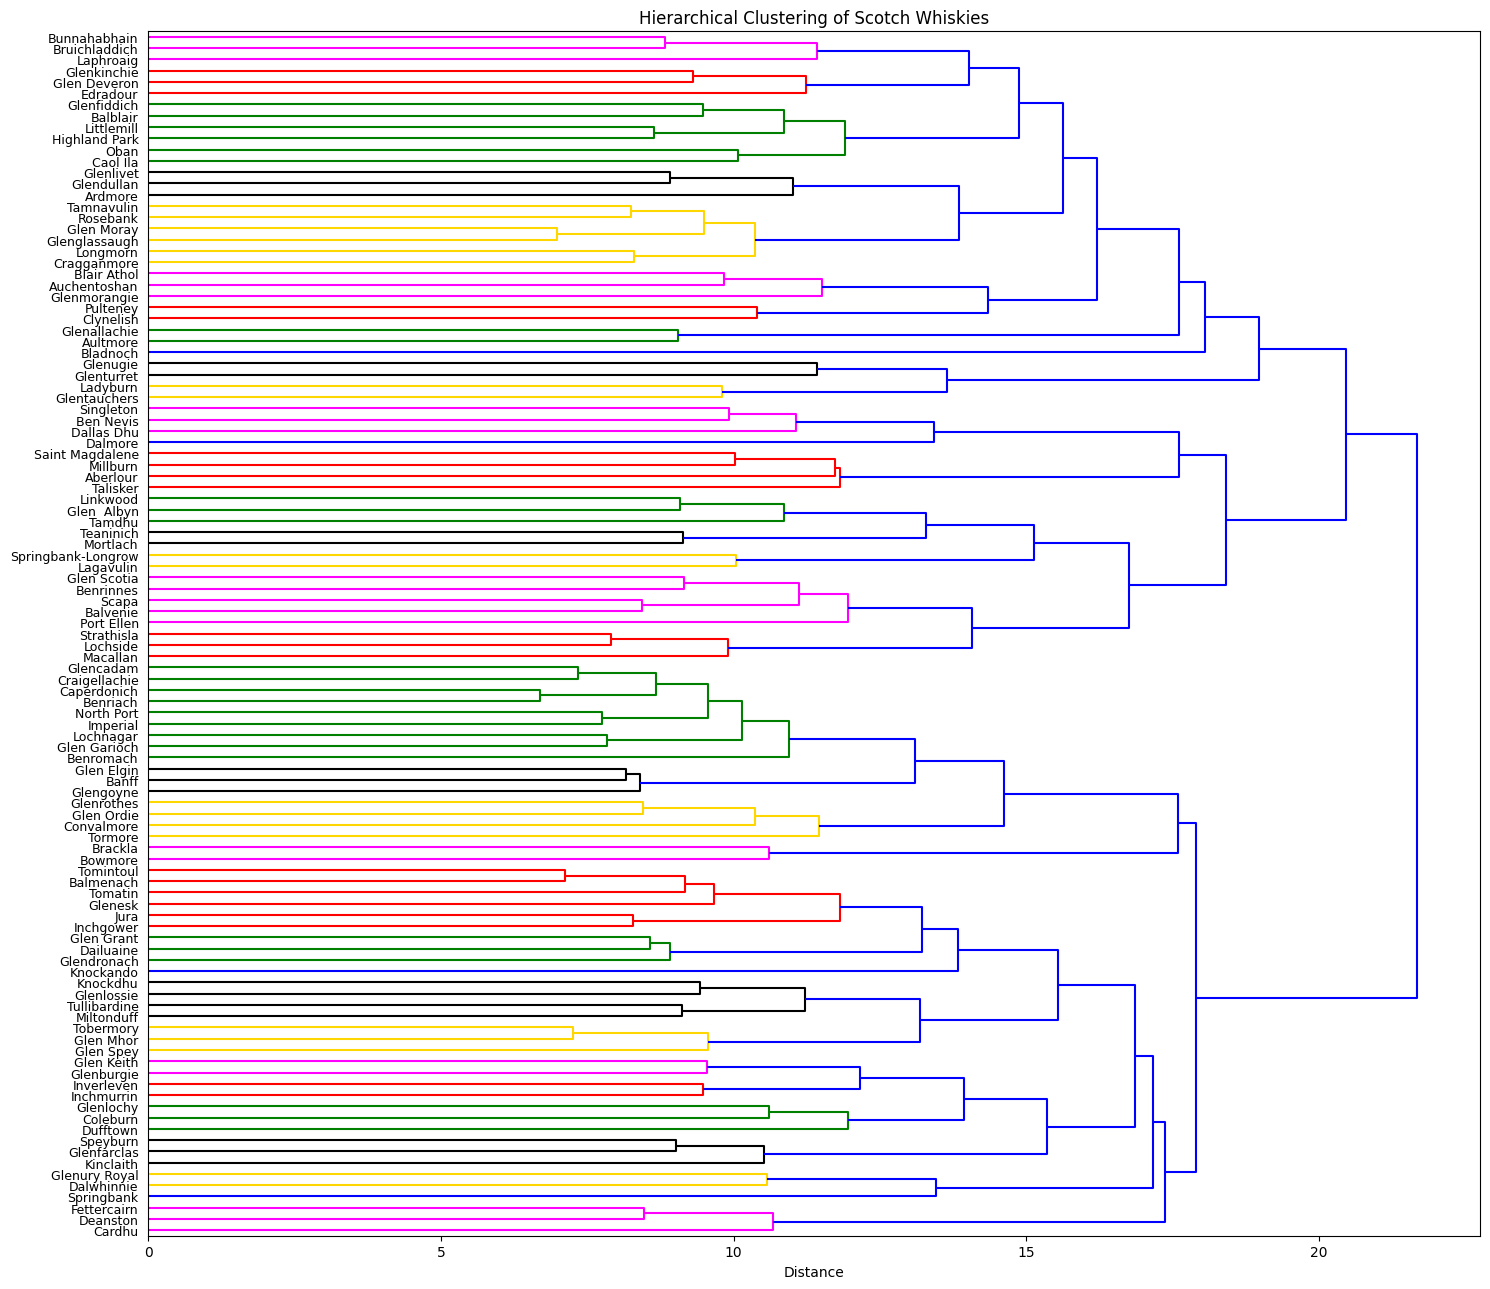

In [76]:
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
import matplotlib.pyplot as plt

# build scaled data from the cleaned feature matrix
X_scaled = StandardScaler().fit_transform(df_features)

# linkage from the same rows
Z = linkage(X_scaled, method="ward")

# labels must come from the aligned cleaned dataframe
labels = df_clean["NAME"].tolist()

# print(len(labels), X_scaled.shape[0], Z.shape[0] + 1)

set_link_color_palette(["magenta", "gold", "black", "green", "red"])
plt.figure(figsize=(15, 13))
dendrogram(
    Z,
    labels=labels,
    orientation="right",
    leaf_font_size=9,
    color_threshold=12,
    above_threshold_color="blue"
)

plt.title("Hierarchical Clustering of Scotch Whiskies")
plt.xlabel("Distance")
plt.tight_layout()
plt.show()

#### Look at a subset to interprate

This zoomed-in section of the dendrogram highlights several locally coherent clusters of Scotch whiskies based on similarity in their feature profiles. The horizontal axis represents **distance**, so whiskies that **merge at shorter distances are more similar**. For example, the group including Glencadam, Craigellachie, Caperdonich, and Benriach forms a tight cluster, indicating strong similarity in their characteristics. Similarly, Glen Elgin and Banff merge at a relatively low distance, suggesting they share closely related features.


**Colored branches** indicate subclusters below the **chosen threshold**, helping visualize natural groupings. The fact that several clusters merge only at larger distances (toward the right) suggests meaningful separation between groups. For instance, Ardbeg and Bowmore appear more distinct, joining other whiskies at higher distances, which may indicate unique flavor profiles. Overall, this section reveals clear local similarities but also shows that broader group distinctions emerge gradually rather than sharply.


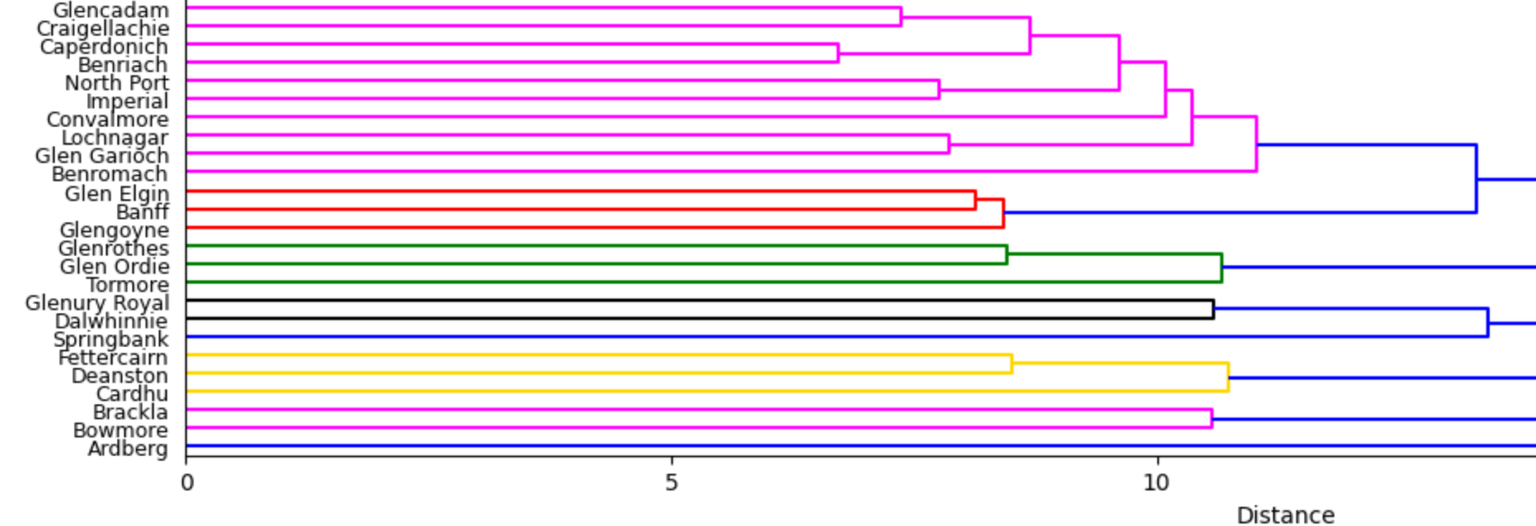

#### What does AgglomerativeClustering do?

In addition to visualizing the dendrogram, AgglomerativeClustering from scikit-learn was used to assign each whiskey to a specific cluster. Based on the dendrogram structure, a cluster number of k=3 was selected. The resulting clusters group whiskies with similar feature profiles, and examining the members of each cluster provides insight into natural groupings within the dataset.

**How to read this result?**

Three main dimensions:

**1. Age**
* Cluster 0 → older
* Cluster 1 & 2 → younger

**2. Color / appearance**
* Cluster 1 → gold-heavy
* Cluster 2 → amber tones
* Cluster 0 → mixed

**3. Quality / finish**
* Cluster 2 → best (long finish, high score)
* Cluster 1 → weakest
* Cluster 0 → middle


#### Run AgglomerativeClustering

In [69]:
from sklearn.cluster import AgglomerativeClustering

# choose number of clusters (e.g., 3 or 4 based on dendrogram)
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")

agg_labels = agg.fit_predict(X_scaled)

df_clean["Agg_Cluster"] = agg_labels

#### Summary
The cluster summary represents the **average feature values** for each group of whiskies. For **binary variables**, values indicate the proportion of whiskies in the cluster exhibiting that characteristic, while **numeric variables** such as age and score represent cluster averages. For example, Cluster 0: wyne = 0.235 can be interprate as "23.5% of whiskies in this cluster have wyne feature."

**What are the features of each clusters?**

* **Cluster 0:** A more “classic” group — older, balanced whiskies with moderate richness and complexity.

* **Cluster 1:** A lighter, younger cluster — more visually rich (gold tones), but simpler and lower-rated overall.

* **Cluster 2:** A distinctive, higher-quality cluster — richer color and longer finish, suggesting more complex flavor profiles.

In [67]:
df_features_with_cluster = df_features.copy()
df_features_with_cluster["Agg_Cluster"] = agg_labels

cluster_summary = df_features_with_cluster.groupby("Agg_Cluster").mean()

print(cluster_summary)

                 wyne    yellow    v.pale      pale    p.gold      gold  \
Agg_Cluster                                                               
0            0.235294  0.058824  0.058824  0.029412  0.176471  0.176471   
1            0.000000  0.000000  0.000000  0.057692  0.076923  0.269231   
2            0.000000  0.000000  0.000000  0.000000  0.000000  0.043478   

               o.gold    f.gold    bronze   p.amber  ...   arome.1      ling  \
Agg_Cluster                                          ...                       
0            0.000000  0.088235  0.000000  0.000000  ...  0.029412  0.058824   
1            0.038462  0.423077  0.096154  0.000000  ...  0.115385  0.076923   
2            0.000000  0.086957  0.000000  0.173913  ...  0.000000  0.217391   

                 long      very     quick       AGE      DIST      SCORE  \
Agg_Cluster                                                                
0            0.235294  0.000000  0.029412  8.970588  3.411765  77.35294

### (2) KMeans

KMeans groups whiskies by assigning each to the nearest cluster centroid, iteratively refining cluster centers.

In Chapter 6, the number of clusters is not known in advance and must be explored. Here, we examine both the elbow plot and silhouette scores. A reasonable k is 2.

#### Standardize

In [71]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

#### Chosing k: Elbow Method

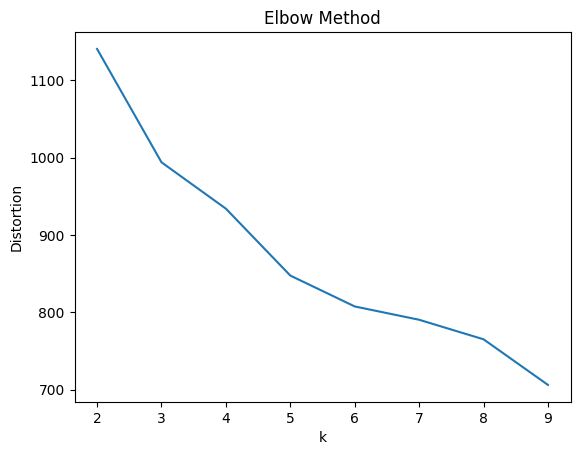

In [11]:
from sklearn.cluster import KMeans

distortions = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    distortions.append(kmeans.inertia_)

plt.plot(K, distortions)
plt.xlabel("k")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

#### Choosing k: Silhouette Scores

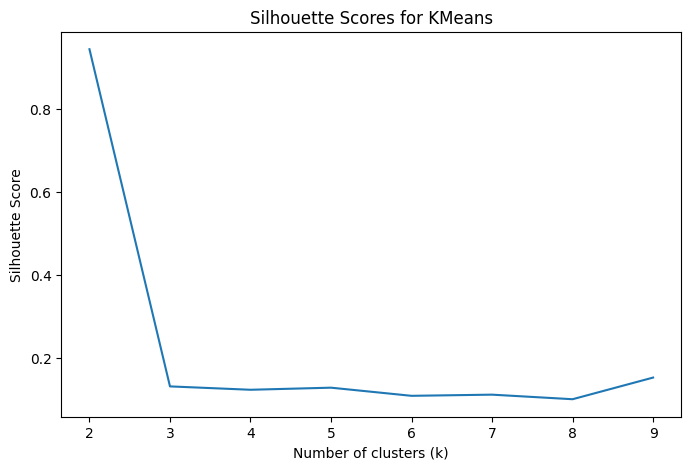

k = 2, silhouette score = 0.942
k = 3, silhouette score = 0.133
k = 4, silhouette score = 0.124
k = 5, silhouette score = 0.129
k = 6, silhouette score = 0.110
k = 7, silhouette score = 0.113
k = 8, silhouette score = 0.102
k = 9, silhouette score = 0.154


In [12]:
from sklearn.metrics import silhouette_score

scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans")
plt.show()

for k, s in zip(K, scores):
    print(f"k = {k}, silhouette score = {s:.3f}")

#### Run KMeans

While k=2 provides the best separation according to the both methods, using only two clusters may oversimplify the diversity of flavor profiles. Therefore, compare k = 2 to k = 4 and see interpretability and segmentation detail.

#### PCA

The PCA plot shows substantial **overlap** among the four KMeans clusters, with **no clear boundaries** separating groups. Points from different clusters are intermixed across the space, indicating **weak structure**. This suggests **KMeans fails to capture meaningful segmentation**, as the data does not form distinct, well-separated clusters in the feature space.

Comparing k=2 and k=4, the **k=2** clustering shows **clearer** separation, while **k=4** produces **overlapping** and fragmented clusters. This suggests that increasing k forces artificial segmentation without revealing meaningful structure, indicating that **KMeans is not well-suited for this dataset**.

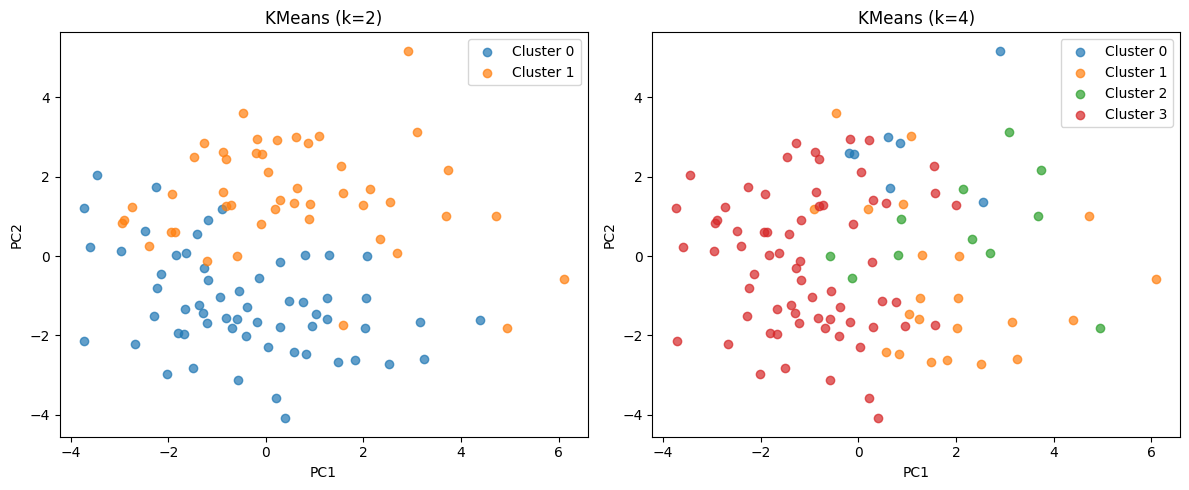

In [82]:
from sklearn.decomposition import PCA

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans for k=2 and k=4
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_scaled)

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- k = 2 ---
for i in range(2):
    axes[0].scatter(
        X_pca[labels_2 == i, 0],
        X_pca[labels_2 == i, 1],
        label=f"Cluster {i}",
        alpha=0.7
    )

axes[0].set_title("KMeans (k=2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# --- k = 4 ---
for i in range(4):
    axes[1].scatter(
        X_pca[labels_4 == i, 0],
        X_pca[labels_4 == i, 1],
        label=f"Cluster {i}",
        alpha=0.7
    )

axes[1].set_title("KMeans (k=4)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

The results show that **KMeans is not effective for this dataset**. Silhouette scores are low, and PCA plots reveal heavy overlap between clusters, indicating weak separation.

In contrast, **hierarchical clustering performs better**. The dendrogram reveals meaningful local groupings and allows flexible interpretation without forcing a fixed number of clusters.

Overall, **the data lacks strong global cluster structure**, making hierarchical clustering a more suitable method for understanding similarity in this dataset.